# IKpy Quickstart #

Import the IKPy module : 

In [1]:
import ikpy.chain
import numpy as np
import ikpy.utils.plot as plot_utils

The basic element of IKPy is the kinematic `Chain`.
To create a chain from an URDF file : 

In [2]:
# will give warnings, that's OK
my_chain = ikpy.chain.Chain.from_urdf_file("./ur5/ur5_gripper.urdf")

/home/ryan/lab-2-ik/.pixi/envs/default/lib/python3.12/site-packages/ikpy/chain.py:60: UserWarning: Link Base link (index: 0) is of type 'fixed' but set as active in the active_links_mask. In practice, this fixed link doesn't provide any transformation so is as it were inactive
  warnings.warn("Link {} (index: {}) is of type 'fixed' but set as active in the active_links_mask. In practice, this fixed link doesn't provide any transformation so is as it were inactive".format(link.name, link_index))
/home/ryan/lab-2-ik/.pixi/envs/default/lib/python3.12/site-packages/ikpy/chain.py:60: UserWarning: Link ee_fixed_joint (index: 7) is of type 'fixed' but set as active in the active_links_mask. In practice, this fixed link doesn't provide any transformation so is as it were inactive
  warnings.warn("Link {} (index: {}) is of type 'fixed' but set as active in the active_links_mask. In practice, this fixed link doesn't provide any transformation so is as it were inactive".format(link.name, link_ind

# Inverse kinematics

In Inverse Kinematics, you want the "end effector" of your robot to reach a specific 3D position (and in general, orientation) in space. The end effector is the final link of the robot arm, furthest from the base, and possibly a tool that is attached (a gripper in our robot model).

To have a more general representation of position, IKPy works with homogeneous coordinates. Homogenous coordinates are represented as a 4x4 matrix storing both position and orientation. Here we only consider (x,y,z) position, not orientation of the chain.

In [7]:
# define target X, Y, Z coordinate
target_position = [ 0.1, -0.2, 0.1]

In [8]:
# run inverse kinematics solver
print("The joint angles are : ", my_chain.inverse_kinematics(target_position))

The joint angles are :  [ 0.         -1.55516677 -1.20894708  2.32791446 -0.53209973 -1.72066415
  0.          0.        ]


You can check that the Inverse Kinematics is correct by comparing with the original position vector : 

In [9]:
# run forward kinematics on the inverse kinematics solution to verify
real_frame = my_chain.forward_kinematics(my_chain.inverse_kinematics(target_position))
print("Computed position vector : %s, goal position vector : %s" % (real_frame[:3, 3], target_position))

Computed position vector : [ 0.1 -0.2  0.1], goal position vector : [0.1, -0.2, 0.1]


# Plotting
And finally plot the result : 

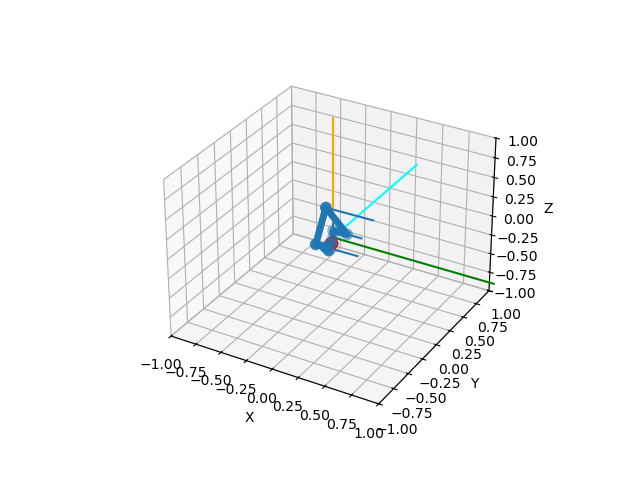

In [13]:
%matplotlib notebook
%matplotlib ipympl

import matplotlib.pyplot as plt
fig, ax = plot_utils.init_3d_figure()

target_position = [ 0.1, -0.2, 0.1]

my_chain.plot(my_chain.inverse_kinematics(target_position), ax, target=target_position)


In [16]:
import numpy as np

# Use the same variable name your notebook uses for the loaded chain
# (often "chain" or "my_chain"); rename below if needed.
reach = 1.18
targets = {
    "+x": [reach, 0, 0],
    "-x": [-reach, 0, 0],
    "+y": [0, reach, 0],
    "-y": [0, -reach, 0],
    "+z": [0, 0, reach],
}

for name, target in targets.items():
    angles = my_chain.inverse_kinematics(target)
    actual = my_chain.forward_kinematics(angles)[:3, 3]
    dist_from_base = np.linalg.norm(actual)
    miss = np.linalg.norm(actual - np.array(target))
    print(f"{name}: target={target}  actual={np.round(actual, 3)}  "
          f"reached {dist_from_base:.3f} m from base, missed by {miss:.3f} m")

+x: target=[1.18, 0, 0]  actual=[ 0.947 -0.     0.018]  reached 0.947 m from base, missed by 0.233 m
-x: target=[-1.18, 0, 0]  actual=[-0.913  0.     0.02 ]  reached 0.914 m from base, missed by 0.267 m
+y: target=[0, 1.18, 0]  actual=[0.    0.913 0.02 ]  reached 0.914 m from base, missed by 0.267 m
-y: target=[0, -1.18, 0]  actual=[ 0.    -0.913  0.02 ]  reached 0.914 m from base, missed by 0.267 m
+z: target=[0, 0, 1.18]  actual=[-0.014  0.076  0.992]  reached 0.995 m from base, missed by 0.203 m


In [17]:
import numpy as np

robot = my_chain

# Sample points uniformly on a sphere bigger than the arm's reach (1.5 m),
# so the IK solver stretches the arm fully toward each one.
rng = np.random.default_rng(0)
n_samples = 300
radius = 1.5

directions = rng.normal(size=(n_samples, 3))
directions /= np.linalg.norm(directions, axis=1, keepdims=True)
targets = radius * directions

# For each target, solve IK, then use FK to get the actual end-effector position
reached = []
for target in targets:
    angles = robot.inverse_kinematics(target)
    actual = robot.forward_kinematics(angles)[:3, 3]
    reached.append(actual)
reached = np.array(reached)

np.set_printoptions(precision=3, suppress=True)
print(f"{len(reached)} reachable boundary points (x, y, z):")
print(reached)

300 reachable boundary points (x, y, z):
[[ 0.19  -0.2    0.998]
 [ 0.157 -0.802  0.573]
 [ 0.687  0.499 -0.337]
 [-0.852 -0.42   0.061]
 [-0.811 -0.076 -0.4  ]
 [-0.706 -0.524 -0.271]
 [ 0.344  0.87  -0.074]
 [ 0.842 -0.41   0.249]
 [ 0.704  0.073 -0.544]
 [-0.734 -0.364  0.215]
 [-0.909 -0.188 -0.11 ]
 [ 0.777  0.308  0.541]
 [-0.632 -0.125  0.787]
 [ 0.595 -0.502  0.634]
 [ 0.817  0.474  0.193]
 [-0.127  0.59   0.823]
 [ 0.763  0.557  0.184]
 [-0.858 -0.003  0.497]
 [-0.88   0.27   0.325]
 [ 0.422 -0.718 -0.367]
 [-0.196 -0.526  0.813]
 [-0.708  0.47  -0.335]
 [ 0.709  0.591  0.315]
 [-0.922  0.022  0.318]
 [ 0.462 -0.285  0.869]
 [-0.714 -0.358  0.538]
 [ 0.023  0.949  0.122]
 [-0.435 -0.259 -0.714]
 [-0.806  0.397  0.398]
 [ 0.569 -0.332  0.773]
 [-0.162  0.887 -0.21 ]
 [-0.568  0.193  0.826]
 [ 0.095 -0.346 -0.754]
 [-0.769  0.276  0.574]
 [-0.116 -0.76   0.648]
 [-0.781 -0.435  0.41 ]
 [-0.893  0.153 -0.197]
 [ 0.451 -0.313  0.864]
 [ 0.395 -0.431  0.838]
 [ 0.447  0.519  0.747]

Convex hull volume: 3.423 m^3
Distance from base: min 0.834 m, max 1.038 m, mean 0.945 m
x range: -0.946 to 0.930 m
y range: -0.943 to 0.949 m
z range: -0.854 to 1.028 m


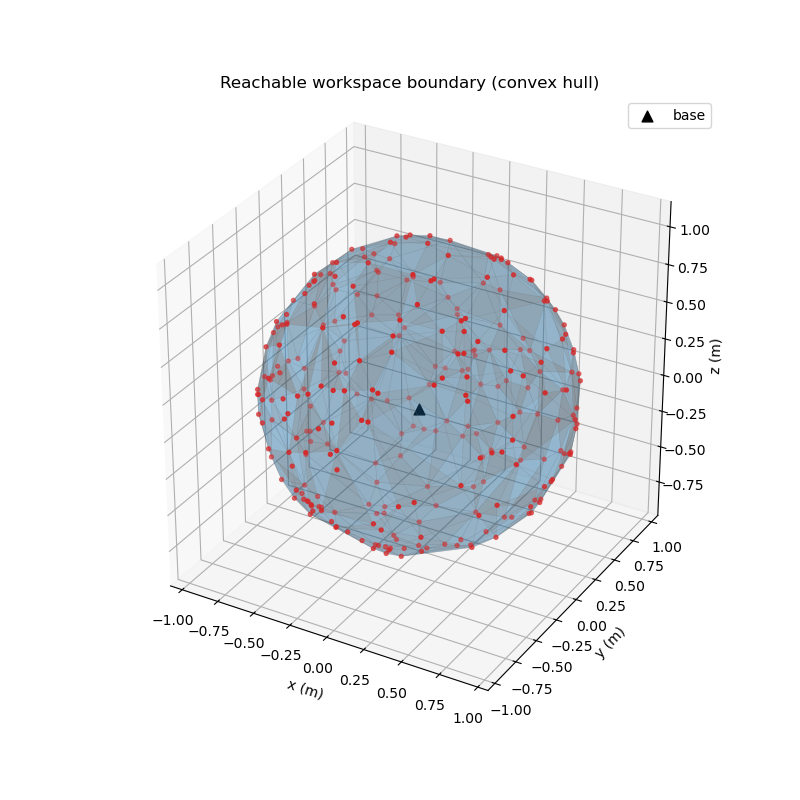

In [19]:
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt

hull = ConvexHull(reached)
dist = np.linalg.norm(reached, axis=1)

print(f"Convex hull volume: {hull.volume:.3f} m^3")
print(f"Distance from base: min {dist.min():.3f} m, max {dist.max():.3f} m, mean {dist.mean():.3f} m")
for i, axis in enumerate("xyz"):
    print(f"{axis} range: {reached[:, i].min():.3f} to {reached[:, i].max():.3f} m")

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
ax.plot_trisurf(reached[:, 0], reached[:, 1], reached[:, 2],
                triangles=hull.simplices, alpha=0.25, edgecolor="gray", linewidth=0.3)
ax.scatter(reached[:, 0], reached[:, 1], reached[:, 2], s=8, color="tab:red")
ax.scatter(0, 0, 0, s=60, color="black", marker="^", label="base")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)")
ax.set_box_aspect((1, 1, 1))
ax.set_title("Reachable workspace boundary (convex hull)")
ax.legend()
plt.show()